# Telco Customer Segmentation using Unsupervised Learning

## Objective
Analyze telecom customers using demographic and service usage data, and group them using clustering techniques to identify distinct customer segments for targeted retention strategies.

## 1. Environment Setup

In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn -q

## 2. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

## 3. Load Dataset

In [3]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 4. Exploratory Data Analysis

In [4]:
print('Shape:', df.shape)
df.info()
df.describe()

Shape: (7043, 21)
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   s

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


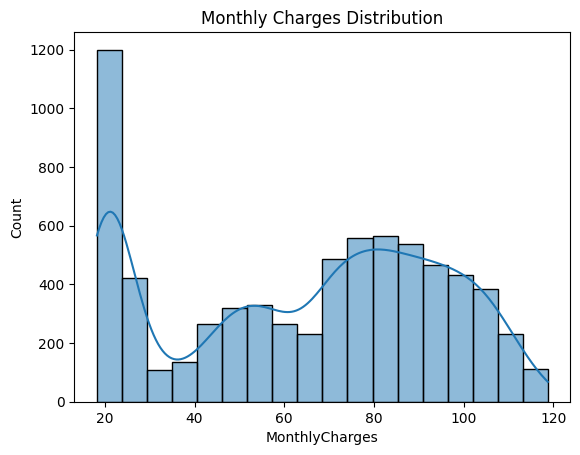

In [5]:
sns.histplot(df['MonthlyCharges'], kde=True)
plt.title('Monthly Charges Distribution')
plt.show()

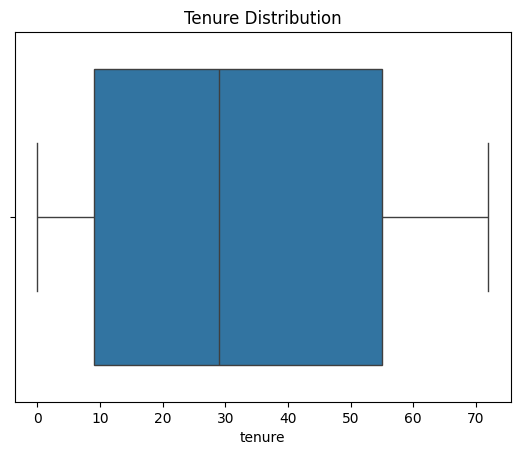

In [6]:
sns.boxplot(x=df['tenure'])
plt.title('Tenure Distribution')
plt.show()

## 5. Data Preparation

In [7]:
df.columns = [c.strip().lower() for c in df.columns]
df = df.drop_duplicates()

# Convert totalcharges to numeric
df['totalcharges'] = pd.to_numeric(df['totalcharges'].str.replace(' ', '', regex=False), errors='coerce')
# Fill missing totalcharges with median
df['totalcharges'] = df['totalcharges'].fillna(df['totalcharges'].median())

# Binary and Categorical encoding
cat_cols = ['gender', 'partner', 'dependents', 'phoneservice', 'multiplelines', 
            'internetservice', 'onlinesecurity', 'onlinebackup', 'deviceprotection', 
            'techsupport', 'streamingtv', 'streamingmovies', 'contract', 
            'paperlessbilling', 'paymentmethod', 'churn']
for col in cat_cols:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip().astype('category').cat.codes

print(df.isnull().sum())

customerid          0
gender              0
seniorcitizen       0
partner             0
dependents          0
tenure              0
phoneservice        0
multiplelines       0
internetservice     0
onlinesecurity      0
onlinebackup        0
deviceprotection    0
techsupport         0
streamingtv         0
streamingmovies     0
contract            0
paperlessbilling    0
paymentmethod       0
monthlycharges      0
totalcharges        0
churn               0
dtype: int64

## 6. Feature Normalization

In [8]:
customer_names = df['customerid']
X = df.drop('customerid', axis=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled.shape

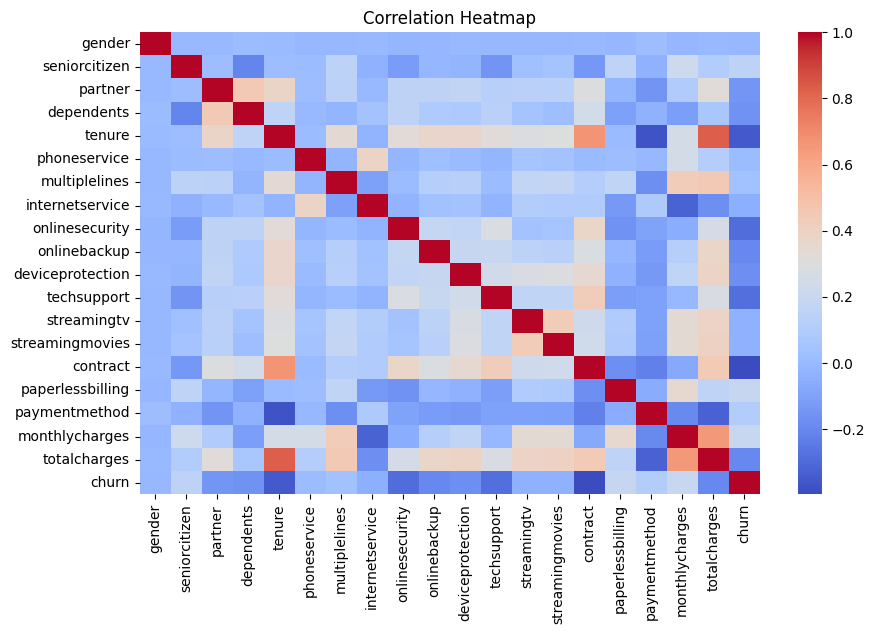

In [9]:
plt.figure(figsize=(10, 6))
sns.heatmap(X.corr(), cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

## 7. Optimal Cluster Selection

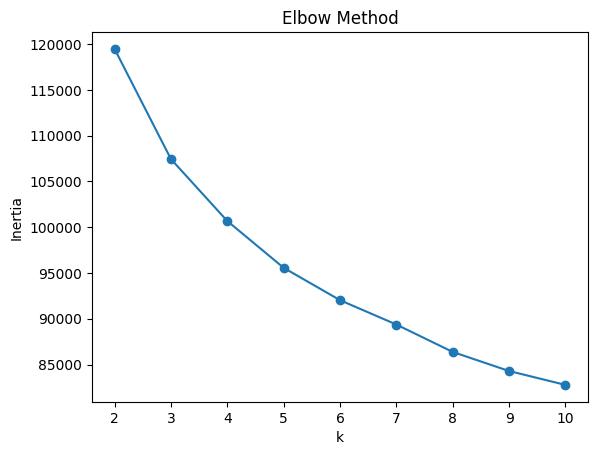

In [10]:
wcss = []
for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    wcss.append(km.inertia_)
plt.plot(range(2, 11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('k')
plt.ylabel('Inertia')
plt.show()

## 8. K-Means Clustering

In [11]:
best_k = 3
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df['kmeans_cluster'] = kmeans.fit_predict(X_scaled)
df['kmeans_cluster'].value_counts()

kmeans_cluster
1    3139
0    2338
2    1566

## 9. Cluster Quality Assessment

In [12]:
score = silhouette_score(X_scaled, df['kmeans_cluster'])
print('Silhouette Score:', score)

Silhouette Score: 0.13363034455717226

The silhouette score validates the separation of the selected cluster configuration and indicates reasonable segmentation of telecom customers.

## 10. DBSCAN Analysis

In [13]:
dbscan = DBSCAN(eps=2.5, min_samples=5)
df['dbscan_cluster'] = dbscan.fit_predict(X_scaled)
df['dbscan_cluster'].value_counts()

dbscan_cluster
 1     2785
-1     1726
 2     1473
 5      643
 0      210
 7       51
 6       47
 3       22
 11      17
 4        8
 12       8
 9        6
 15       6
 16       6
 17       5
 8        5
 13       5
 14       5
 10       3
 20       3
 22       3
 18       3
 21       2
 19       1

## 11. Dimensionality Reduction using PCA

In [14]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['Cluster'] = df['kmeans_cluster']

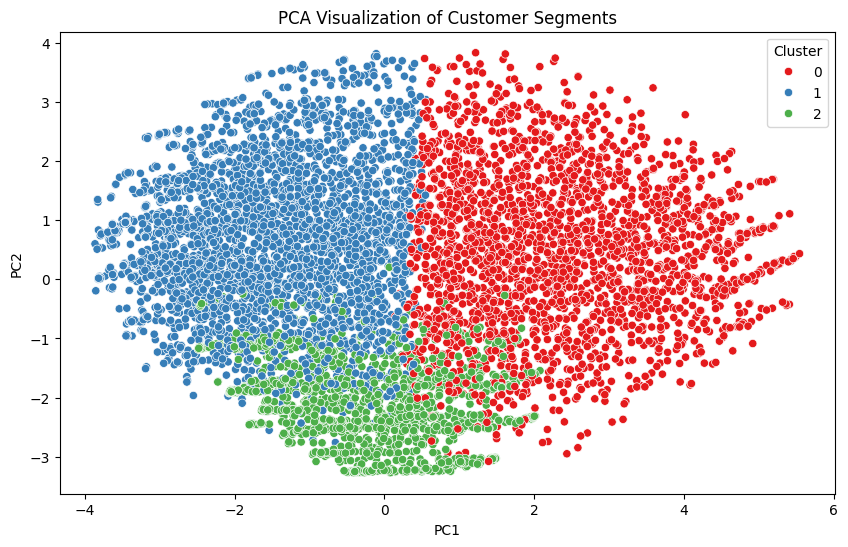

In [15]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='Cluster', palette='Set1')
plt.title('PCA Visualization of Customer Segments')
plt.show()

The PCA scatterplot provides a two-dimensional representation of the clustered customers, displaying distinct clusters that align with customer usage behavior.

## 12. Cluster Characteristics

In [16]:
pd.set_option('display.max_columns', None)
df.groupby('kmeans_cluster').mean(numeric_only=True)

,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn,dbscan_cluster
kmeans_cluster,,,,,,,,,,,,,,,,,,,,,
0,0.504705,0.183918,0.704876,0.374251,55.457228,0.903336,1.418306,0.573567,1.150984,1.370830,1.452951,1.214286,1.471771,1.470060,1.212575,0.667665,1.102652,88.313815,4921.637970,0.123610,0.907186
1,0.501115,0.211214,0.314431,0.177445,16.109270,0.859509,0.832431,0.558777,0.409047,0.513539,0.448550,0.378464,0.627588,0.642243,0.104173,0.690984,1.791972,68.461803,1107.597149,0.468621,1.168844
2,0.512133,0.031290,0.489783,0.432950,30.500639,0.990421,0.443806,1.949553,1.014687,1.000639,0.999361,1.013410,0.976373,0.981481,1.086207,0.281609,1.842273,22.182184,694.766220,0.069604,2.056833


## 13. Key Findings

### Finding 1
**Cluster 0 - High-Value Loyalists**: Represents long-term customers with high tenure (average ~55 months) and high total charges who subscribe to multiple additional services and have long-term contracts. They have a very low churn rate of around 12%.

### Finding 2
**Cluster 1 - High-Churn Transients**: Newer, single customers on month-to-month contracts. They have low tenure (average ~16 months) but moderate monthly charges, and display an extremely high churn rate of approximately 47%.

### Finding 3
**Cluster 2 - Low-Cost Loyalists**: Loyal customers with moderate tenure (~30 months) but very low monthly charges (~$22). They primarily use only basic phone services without internet and have a low churn rate of around 7%.

### Finding 4
Longer tenure and long-term contract types are strongly associated with higher total lifetime value and significantly lower customer churn.

### Finding 5
DBSCAN identified a group of outlier customers with distinct demographic or service combinations that differ from the three main customer segments.

## 14. Conclusion

This study successfully applied unsupervised learning techniques to segment telecom customers. K-Means clustering revealed three distinct segments based on tenure, monthly charges, contracts, and service subscriptions, which have very different churn rates. DBSCAN highlighted exceptional customer profiles, while PCA provided a clear two-dimensional visualization of the customer segments. These findings enable targeted retention strategies, such as offering contract upgrades to High-Churn Transients (Cluster 1) to reduce overall churn.